# Structural robustness of mammalian transcription factor networks reveals plasticity across development

## Human Analysis

#### External imports

In [1]:
import os
import pandas as pd
import networkx as nx
import numpy as np
import re

#### Auxiliar Fxns

In [2]:
def get_human_names(root, code_names):
    name = re.split('buffer.5000', root)
    name = name[1]
    name = name.replace('\\','')
    return code_names[name]

In [3]:
def extract_networks(directory_name=str, files_ignore=list, cols=tuple, feo=True, code_names=dict):
    networks = {}
    for root, dir, files in os.walk(directory_name):
        if len(files) != 0 and files[0] not in files_ignore:
          path = os.path.join(os.getcwd(), root, files[0])
          net = nx.DiGraph()
          name = get_human_names(root, code_names)
          if feo:
               f = np.genfromtxt(path, dtype= str, delimiter='\t', usecols= cols)
               net.add_edges_from(f)
          else:
               net = nx.read_edgelist(path, create_using= nx.DiGraph)
          
          networks[name] = net
    return networks

#### Biological Networks

In [5]:
hg19CellTypeValues = { "AG10803-DS12374" : "skin fibroblast (abdomen)",
"AoAF-DS13513" : "aortic adventitial fibroblast",
"CD20-DS18208" : "B-cells (CD20+)",
"CD34-DS12274" : "Hematopoietic stem/progenitor cells (CD34+)",
"fBrain-DS11872" : "fetal brain",
"fHeart-DS12531" : "fetal heart",
"fLung-DS14724" : "fetal lung",
"GM06990-DS7748" : "B-lymphoblastoid cells (individual 06990)",
"GM12865-DS12436" : "B-lymphoblastoid cells (individual 12865)",
"HAEpiC-DS12663" : "amniotic epithelium",
"HAh-DS15192" : "hippocampal astrocyte",
"HCF-DS12501" : "cardiac fibroblast",
"HCM-DS12599" : "cardiac myocyte",
"HCPEpiC-DS12447" : "choroid plexus epithelium",
"HEEpiC-DS12763" : "esophageal epithelium",
"HepG2-DS7764" : "hepatic (hepatoblastoma)",
"hESCT0-DS11909": "embryonic stem cells (line H7)",
"HFF-DS15115" : "foreskin fibroblast",
"HIPEpiC-DS12684" : "iris pigment epithelium",
"HMF-DS13368" : "mammary fibroblast",
"HMVEC_dBlAd-DS13337" : "microvascular endothelium, adult, blood",
"HMVEC_dBlNeo-DS13242" : "microvascular endothelium, neonatal, blood",
"HMVEC_dLyNeo-DS13150" : "microvascular endothelium, neonatal, lympathic",
"HMVEC_LLy-DS13185" : "microvascular endothelium, lung-derived",
"HPAF-DS13411" : "pulmonary artery fibroblast",
"HPdLF-DS13573" : "periodontal ligament fibroblast",
"HPF-DS13390" : "pulmonary fibroblast",
"HRCE-DS10666" : "renal cortical epithelium",
"HSMM-DS14426" : "skeletal muscle myoblast",
"hTH1-DS7840" : "Th1 T-cells",
"HVMF-DS13981" : "villous mesenchymal fibroblast",
"IMR90-DS13219" : "pulmonary fibroblast, fetal",
"K562-DS9767" : "erythroid (erythroleukemia)",
"NB4-DS12543" : "granulocytic (promyelocytic leukemia)",
"NHA-DS12800" : "astrocyte",
"NHDF_Ad-DS12863" : "dermal fibroblast, adult",
"NHDF_Neo-DS11923" : "dermal fibroblast, neonatal",
"NHLF-DS12829" : "lung fibroblast",
"SAEC-DS10518" : "small airway epithelium",
"SkMC-DS11949" : "skeletal myocytes",
"SKNSH-DS8482" : "neuroblastoid (neuroblastoma)"
}

human_networks = extract_networks('g:\\Mi unidad\\Respaldo\\Genomicas\\netective\\data\\human_net', [], (0,1), feo=False, code_names=hg19CellTypeValues)
human_networks

{'aortic adventitial fibroblast': <networkx.classes.digraph.DiGraph at 0x2020fb30040>,
 'B-cells (CD20+)': <networkx.classes.digraph.DiGraph at 0x2020fb300a0>,
 'Hematopoietic stem/progenitor cells (CD34+)': <networkx.classes.digraph.DiGraph at 0x2020fb30130>,
 'fetal brain': <networkx.classes.digraph.DiGraph at 0x2020fb300d0>,
 'fetal heart': <networkx.classes.digraph.DiGraph at 0x2020fb30100>,
 'fetal lung': <networkx.classes.digraph.DiGraph at 0x2020fb30070>,
 'B-lymphoblastoid cells (individual 06990)': <networkx.classes.digraph.DiGraph at 0x2020fb301c0>,
 'B-lymphoblastoid cells (individual 12865)': <networkx.classes.digraph.DiGraph at 0x2020fb30160>,
 'amniotic epithelium': <networkx.classes.digraph.DiGraph at 0x2020fb30250>,
 'hippocampal astrocyte': <networkx.classes.digraph.DiGraph at 0x2020fb301f0>,
 'cardiac fibroblast': <networkx.classes.digraph.DiGraph at 0x2020fb30190>,
 'cardiac myocyte': <networkx.classes.digraph.DiGraph at 0x2020fb302b0>,
 'choroid plexus epithelium': 

In [6]:
test = {
    i : j 
    for k, (i,j) in enumerate(human_networks.items())
    if k < 5
}
test

{'aortic adventitial fibroblast': <networkx.classes.digraph.DiGraph at 0x2020fb30040>,
 'B-cells (CD20+)': <networkx.classes.digraph.DiGraph at 0x2020fb300a0>,
 'Hematopoietic stem/progenitor cells (CD34+)': <networkx.classes.digraph.DiGraph at 0x2020fb30130>,
 'fetal brain': <networkx.classes.digraph.DiGraph at 0x2020fb300d0>,
 'fetal heart': <networkx.classes.digraph.DiGraph at 0x2020fb30100>}

In [85]:
from freyrelab.nets import dissimilarity

dissimilarity.graph_dissimilarity(test['Hematopoietic stem/progenitor cells (CD34+)'], test['fetal brain'], [0.45, 0.45, 0.1], kdir='out'), dissimilarity.graph_dissimilarity(test['Hematopoietic stem/progenitor cells (CD34+)'], test['fetal brain'], [0.45, 0.45, 0.1])

(0.07199578766744717, 0.07268701887632725)

In [43]:
for i, j in test.items():
    name = i.replace('/', '_')
    nx.write_edgelist(j, path=f'{name}', delimiter='\t', encoding='utf-8', data=False)

#### Synthetic networks

ER and BA analogous ensembles to each biological network.

In [76]:
from freyrelab.nets import models

seed = 42
synth_graphs = {}

for net_id, G in human_networks.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    for i in range(1,2):
        synth_graphs[f'BA_{net_id}_{i}'] = nx.DiGraph(models.barabasi_albert_graph(n))
        synth_graphs[f'ER_{net_id}_{i}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)

networks = {**human_networks, **synth_graphs}

#### Graphs overall info

In [77]:
nets_info = {'Cell Type': [],
        'Nodes': [],
        'Edges': [],
        'Density': []
        }

for name,G in networks.items():
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = n_edges / (n_nodes * (n_nodes - 1))
    nets_info['Cell Type'].append(name)
    nets_info['Nodes'].append(n_nodes)
    nets_info['Edges'].append(n_edges)
    nets_info['Density'].append(density)

info_df = pd.DataFrame.from_dict(nets_info)
info_df

,Cell Type,Nodes,Edges,Density
0,aortic adventitial fibroblast,529,14795,0.052969
1,B-cells (CD20+),515,16723,0.063175
2,Hematopoietic stem/progenitor cells (CD34+),526,16461,0.059609
3,fetal brain,519,11698,0.043513
4,fetal heart,516,14295,0.053793
...,...,...,...,...
118,ER_skeletal myocytes_1,529,17190,0.061544
119,BA_neuroblastoid (neuroblastoma)_1,508,2002,0.007773
120,ER_neuroblastoid (neuroblastoma)_1,508,12646,0.049100
121,BA_skin fibroblast (abdomen)_1,521,2052,0.007574


### Netective Analysis

In [8]:
from netective import compare_structure

`!!!!AGUAS!!!!`

Properties used for analysis: 
Average Degree for Nearest Neighbors (Undirected)
Average Local Efficiency
Average Degree for Nearest Neighbors (Out-Out)
Average Shortest Path Length
Betweenness Centrality
Center
Clustering Coefficient
Complex Feed-Forward Circuits
Degree
Density
Diameter
Eccentricity
Entropy of Degree Distribution
Entropy of Out-Degree Distribution
3-Feedback Loops
Gene % in the Giant Component
Gini Index
Global Efficiency
In-Degree
Locality Index
Max Degree
Max In-Dregree
Max Out-Degree
Number of Arcs
Number of Edges
Number of Nodes
Out-Degree
Periphery
Radius
Regulators
Rich Club Coefficient
Self-Loops
Self Regulations
Subgraph Centrality
Undirected Density
Undirected Gini Index




  0%|          | 0/7 [00:00<?, ?it/s]

Running aortic adventitial fibroblast
Running B-cells (CD20+)
Running Hematopoietic stem/progenitor cells (CD34+)
Running fetal brain
Running fetal heart


 71%|███████▏  | 5/7 [00:40<00:16,  8.14s/it]


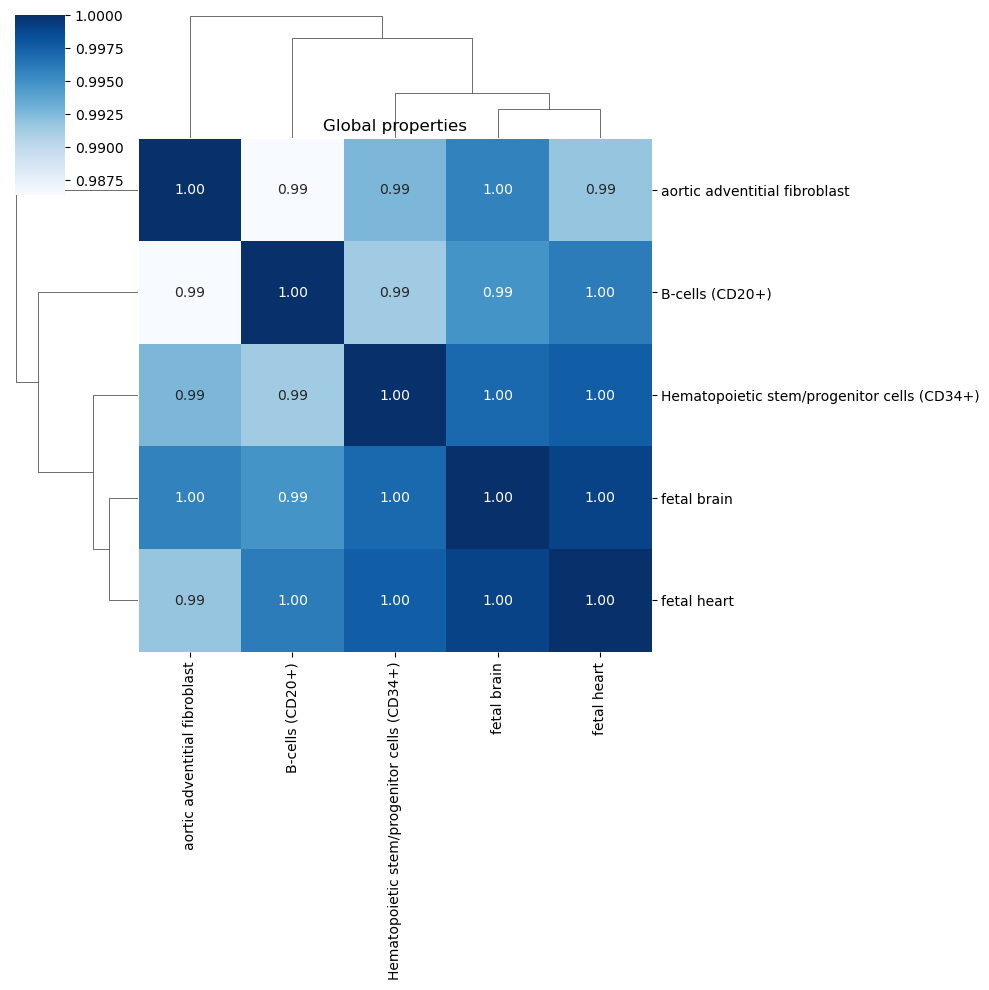

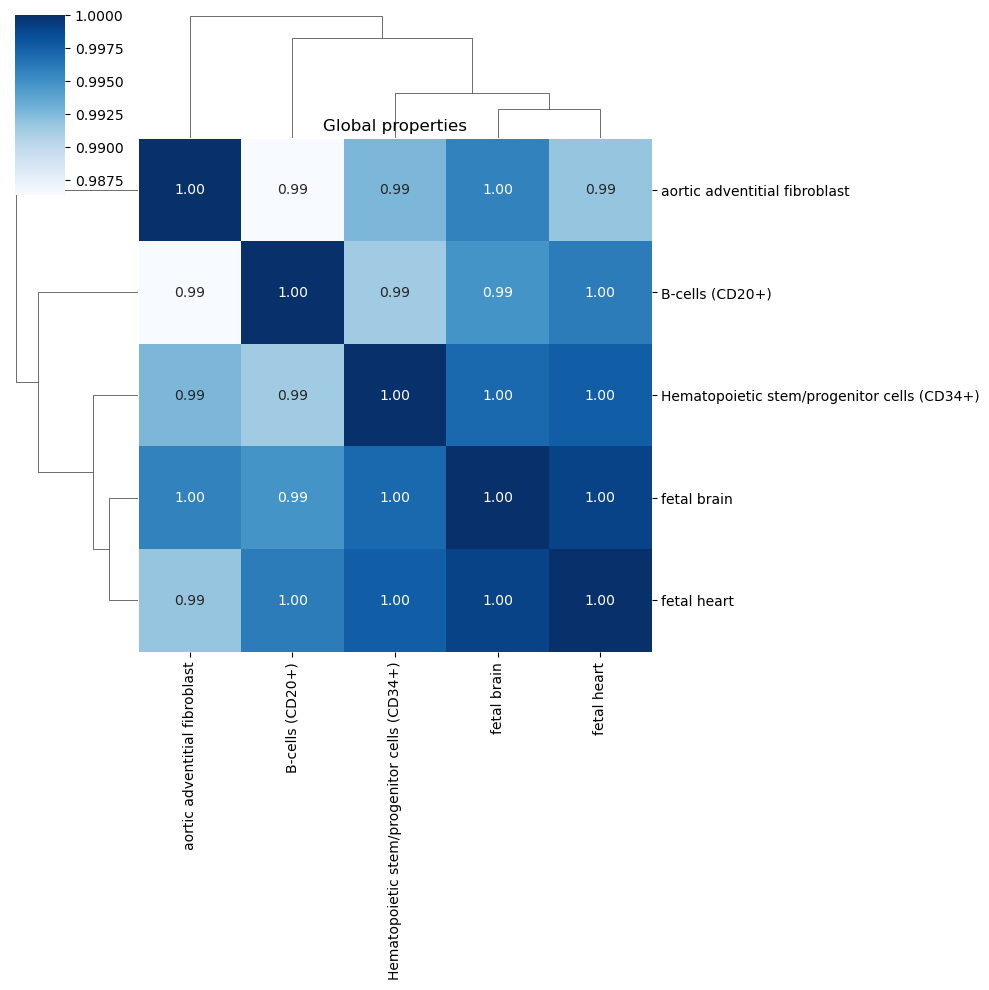

In [9]:
compare_structure(test, norm='biological', workers='auto')